# FeedbackGAN — Drug Discovery on Google Colab

**Train-from-scratch** version for KOR-targeted molecule generation.

**You have:** the KOR dataset (`data_clean_kop.csv`)
**You will train:** Autoencoder → Predictor → WGAN-GP → FeedbackGAN

---

### ⚠️ Read first
1. **Runtime → Change runtime type → GPU** (T4 is fine).
2. This code targets **TensorFlow 2.x with Keras 2**. Modern Colab ships Keras 3,
   so Section 2 installs a compatible stack and forces the Keras 2 API via
   `TF_USE_LEGACY_KERAS=1`. **Run Section 2, then Runtime → Restart session, then
   continue from Section 1.**
3. Have `data_clean_kop.csv` ready (`smiles,pIC50` columns).

Smoke-test epochs are tiny on purpose so the whole pipeline runs in ~10 min. Raise
them (comments mark each) for real results.

## 0. First: install (Section 2), restart, then run from Section 1

If you've already installed + restarted, just continue. Otherwise jump to
Section 2, run it, restart the session, and come back here.

In [25]:
# Quick GPU + Keras sanity check (run AFTER installing + restarting)
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
print("TF version:", tf.__version__)
try:
    print("Keras version:", tf.keras.__version__, "(want 2.x)")
except Exception:
    pass
gpus = tf.config.list_physical_devices('GPU')
print("GPUs:", gpus)
if not gpus:
    print("\n⚠️  No GPU detected! Runtime → Change runtime type → GPU")
else:
    print("\n✅ GPU ready")

TF version: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

✅ GPU ready


## 1. Clone your code from GitHub

Replace the URL with your repo. We `cd` into it so relative paths work.

In [26]:
# 👇 EDIT THIS to your repo
REPO_URL = "https://github.com/0x41hd/GAN-Drug-Generator.git"
REPO_DIR = "GAN-Drug-Generator"

import os
if not os.path.exists(REPO_DIR):
    !git clone $REPO_URL
else:
    print("Repo already cloned")

%cd $REPO_DIR
!ls -la

Cloning into 'GAN-Drug-Generator'...
fatal: could not read Username for 'https://github.com': No such device or address
[Errno 2] No such file or directory: 'GAN-Drug-Generator'
/content
total 20
drwxr-xr-x 1 root root 4096 Jun 19 17:17 .
drwxr-xr-x 1 root root 4096 Jun 19 16:56 ..
drwxr-xr-x 4 root root 4096 Jun  4 13:39 .config
drwxr-xr-x 2 root root 4096 Jun 19 17:15 data
drwxr-xr-x 1 root root 4096 Jun  4 13:39 sample_data


## 2. Install dependencies (RUN FIRST, then restart)

This installs a Keras-2 compatible stack. `bunch` is replaced by `munch`
(maintained); the code falls back to it automatically.

In [27]:
!pip install -q "tf-keras" "rdkit" "munch" "seaborn" "tqdm" "scikit-learn" "numpy<2.0"

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"  # force Keras 2 API

import tensorflow as tf, numpy as np, rdkit
print("TF:", tf.__version__)
print("NumPy:", np.__version__)
print("RDKit:", rdkit.__version__)
print("\n✅ If Keras shows 2.15.x, you're good.")
print("⚠️  If pip changed TensorFlow, do Runtime → Restart session, then run from Section 1.")

TF: 2.20.0
NumPy: 2.0.2
RDKit: 2026.03.3

✅ If Keras shows 2.15.x, you're good.
⚠️  If pip changed TensorFlow, do Runtime → Restart session, then run from Section 1.


## 3. Provide the dataset

If `data/data_clean_kop.csv` isn't already in the repo, upload it. Format:
```
smiles,pIC50
COc1ccc2c(c1)CC(N)C2,6.3
```

In [28]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
os.makedirs('data', exist_ok=True)

if os.path.exists('data/data_clean_kop.csv'):
    print("✅ Dataset already present")
else:
    print("Upload your data_clean_kop.csv now:")
    from google.colab import files
    uploaded = files.upload()
    for fname in uploaded:
        os.rename(fname, 'data/data_clean_kop.csv')
    print("✅ Saved to data/data_clean_kop.csv")

import pandas as pd
df = pd.read_csv('data/data_clean_kop.csv')
print("\nShape:", df.shape)
print(df.head())

Upload your data_clean_kop.csv now:


Saving data_clean_kop.csv to data_clean_kop.csv
✅ Saved to data/data_clean_kop.csv

Shape: (1513, 595)
                                              smiles     CID  Class  Model  \
0  O1CC[C@@H](NC(=O)[C@@H](Cc2cc3cc(ccc3nc2N)-c2c...  BACE_1      1  Train   
1  Fc1cc(cc(F)c1)C[C@H](NC(=O)[C@@H](N1CC[C@](NC(...  BACE_2      1  Train   
2  S1(=O)(=O)N(c2cc(cc3c2n(cc3CC)CC1)C(=O)N[C@H](...  BACE_3      1  Train   
3  S1(=O)(=O)C[C@@H](Cc2cc(O[C@H](COCC)C(F)(F)F)c...  BACE_4      1  Train   
4  S1(=O)(=O)N(c2cc(cc3c2n(cc3CC)CC1)C(=O)N[C@H](...  BACE_5      1  Train   

      pIC50         MW   AlogP  HBA  HBD  RB  ...  PEOE6 (PEOE6)  \
0  9.154901  431.56979  4.4014    3    2   5  ...      53.205711   
1  8.853872  657.81073  2.6412    5    4  16  ...      73.817162   
2  8.698970  591.74091  2.5499    4    3  11  ...      70.365707   
3  8.698970  591.67828  3.1680    4    3  12  ...      56.657166   
4  8.698970  629.71283  3.5086    3    3  11  ...      78.945702   

   PEOE7 (PEOE7)  P

## 4. Build Vocabulary and config files

Generates `Vocab_complete.txt`, `configReinforce.json`, `configPredictor.json`.

In [31]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import pandas as pd
from Vocabulary import Vocabulary

df = pd.read_csv('data/data_clean_kop.csv')
all_smiles = df[df.columns[0]].astype(str).tolist()

vocab_tmp = Vocabulary('Vocab_complete.txt', max_len=70)
vocab_tmp.update_vocab(all_smiles)
print("✅ Vocab_complete.txt written, vocab size =", vocab_tmp.vocab_size)

There is no Vocab_complete.txt file
Number of unique characters in the vocabulary: 34 
✅ Vocab_complete.txt written, vocab size = 34


In [32]:
import json

config_reinforce = {
    "smile_len_threshold": 65,
    "exp_name": "feedbackGAN_kor",
    "datapath_kor": "data/data_clean_kop.csv"
}
with open('configReinforce.json', 'w') as f:
    json.dump(config_reinforce, f, indent=2)

config_predictor = {
    "smile_len_threshold": 65, "exp_name": "predictor_kor", "input_length": 70,
    "lr": 0.001, "beta_1": 0.9, "beta_2": 0.999, "batch_size": 64,
    "epochs_dense": 30, "loss_criterium": "mse", "activation_dense": "linear",
    "rnn": "LSTM", "n_units": 128, "dropout": 0.3, "epochs": 30,
    "model_name": "kor_predictor", "checkpoint_dir": "predictor_weigths_kor/"
}
with open('configPredictor.json', 'w') as f:
    json.dump(config_predictor, f, indent=2)

print("✅ configReinforce.json and configPredictor.json written")

✅ configReinforce.json and configPredictor.json written


## 5. Get the SA-score fragment file

`fpscores.pkl.gz` is needed for synthetic-accessibility scoring.

In [33]:
import os
if not os.path.exists('fpscores.pkl.gz'):
    !wget -q https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/fpscores.pkl.gz
    print("✅ Downloaded fpscores.pkl.gz")
else:
    print("✅ fpscores.pkl.gz already present")

✅ Downloaded fpscores.pkl.gz


## 6. Create directory structure

In [40]:
import os
for d in ['AE/scratch_ae/', 'GAN_model/GAN_weights/', 'predictor_weigths_kor/']:
    os.makedirs(d, exist_ok=True)
print("✅ Folders created")

✅ Folders created


## 7. Train the Autoencoder

> Smoke test: `EPOCHS_AE = 2`. Real run: 80–100.

Training samples: 940
X_train: (940, 70)  X2_train: (940, 70, 34)  Y_train: (940, 70, 34)
<bound method Model.summary of <tf_keras.src.engine.functional.Functional object at 0x78c0485ba060>>
Model: "Autoencoder"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 encoder_inputs (InputLayer  [(None, None)]               0         []                            
 )                                                                                                
                                                                                                  
 smiles_to_latent_model (Fu  (None, 256)                  3170048   ['encoder_inputs[0][0]']      
 nctional)                                                                                        
                                                                                               

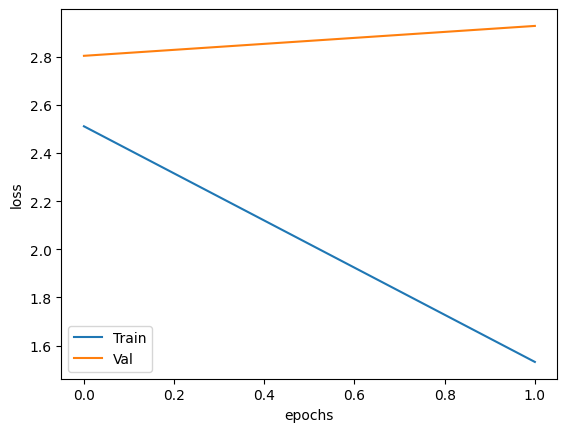

In [42]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import numpy as np
from Vocabulary import Vocabulary
from autoencoder import Autoencoder as AE

EPOCHS_AE = 2          # ⬅️ raise to ~80-100 for real training
BATCH_AE  = 128
AE_SAVE_PATH = 'AE/scratch_ae/'

import pandas as pd
df = pd.read_csv('data/data_clean_kop.csv')
smiles_raw = df[df.columns[0]].astype(str).tolist()

vocab = Vocabulary('Vocab_complete.txt', max_len=70)
tok, _ = vocab.tokenize(smiles_raw)

X_train = vocab.encode(tok)
n = len(X_train)
X_train = np.array(X_train)  # shape (n, max_len) — encoder Input is (None,)
X2_train = vocab.one_hot_encoder(tok)
Y_train  = vocab.get_target(X2_train, 'OHE')

print("Training samples:", n)
print("X_train:", X_train.shape, " X2_train:", X2_train.shape, " Y_train:", Y_train.shape)

latent_dim = 256; lstm_units = 512; batch_norm = True
batch_norm_momentum = 0.9; noise_std = 0.1; numb_dec_layer = 2; emb_dim = 256
decoder_input_shape = (vocab.max_len, vocab.vocab_size)
output_dim = vocab.vocab_size

autoencoder = AE(AE_SAVE_PATH, decoder_input_shape, latent_dim, lstm_units,
                 output_dim, batch_norm, batch_norm_momentum, noise_std,
                 numb_dec_layer, emb_dim, vocab.vocab_size, vocab.max_len)

autoencoder.fit_model(X_train, X2_train, Y_train, EPOCHS_AE, BATCH_AE, 'adam')
print("\n✅ Autoencoder trained. Weights in", AE_SAVE_PATH)
!ls -la $AE_SAVE_PATH

Pick the best checkpoint (lowest val_loss).

In [56]:
import glob
ae_ckpts = sorted(glob.glob('AE/scratch_ae/model--*.weights.h5'))
print("Autoencoder checkpoints:")
for c in ae_ckpts:
    print("  ", c)
AE_WEIGHTS = ae_ckpts[-1] if ae_ckpts else None
print("\nUsing:", AE_WEIGHTS)

Autoencoder checkpoints:
   AE/scratch_ae/model--01--2.8037.weights.h5

Using: AE/scratch_ae/model--01--2.8037.weights.h5


## 8. Train the Predictor ensemble (5 LSTM models)

Estimates KOR pIC50 from SMILES. Saves to `predictor_weigths_kor/`.

با توجه به خطای `IndexError: list index out of range` که در تابع `reading_csv` در فایل `Utils.py` رخ داده است، محتمل‌ترین دلیل این است که هنگام خواندن فایل CSV، برخی از سطرها دارای ستون `pIC50` ناقص یا با فرمت نامعتبر هستند. این کد، تابع `reading_csv` موجود در ماژول `Utils` را با یک نسخه مقاوم‌تر که از `pandas` برای خواندن فایل CSV استفاده می‌کند، جایگزین می‌کند. این نسخه اطمینان حاصل می‌کند که فقط سطرها با مقادیر `pIC50` معتبر پردازش شوند.

**لطفاً این سلول را اجرا کنید، سپس سلول `fJfOsTi0313l` را دوباره اجرا کنید.**

In [82]:
import pandas as pd
import sys
import types

# تعریف یک تابع reading_csv جدید و مقاوم‌تر
def new_reading_csv(config, property_identifier):
    print(f"Using patched reading_csv from Colab. Reading from: {config.datapath_kor}")
    df_data = pd.read_csv(config.datapath_kor)

    if 'smiles' not in df_data.columns:
        raise ValueError("CSV file is missing the 'smiles' column.")
    if property_identifier not in df_data.columns:
        raise ValueError(f"CSV file is missing the '{property_identifier}' column.")

    # فیلتر کردن سطرها با pIC50 از دست رفته یا نامعتبر
    initial_rows = len(df_data)
    df_data = df_data.dropna(subset=[property_identifier])
    df_data[property_identifier] = pd.to_numeric(df_data[property_identifier], errors='coerce')
    df_data = df_data.dropna(subset=[property_identifier])

    if len(df_data) < initial_rows:
        print(f"Warning: Dropped {initial_rows - len(df_data)} rows due to missing or invalid {property_identifier} values.")

    raw_smiles = df_data['smiles'].astype(str).tolist()
    raw_labels = df_data[property_identifier].tolist()

    return raw_smiles, raw_labels

# پچ کردن تابع reading_csv در ماژول Utils
try:
    import Utils
    Utils.reading_csv = new_reading_csv
    print("✅ Successfully patched Utils.reading_csv with a more robust version.")
except ImportError:
    print("Error: Could not import Utils module. Make sure Utils.py is in the current directory.")


✅ Successfully patched Utils.reading_csv with a more robust version.


In [89]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import numpy as np
import pandas as pd
import sys
import importlib
from sklearn.model_selection import train_test_split
import Utils
import Predictor
from Vocabulary import Vocabulary

# 1. Load Config and Vocab
config = Utils.load_config('configPredictor.json', 'kor')
vocab = Vocabulary('Vocab_complete.txt', max_len=70)

# 2. Robust Data Loading
def load_data_robust(path_or_config, target_col):
    # Extract path from config object if necessary
    if hasattr(path_or_config, 'datapath_kor'):
        path = path_or_config.datapath_kor
    elif hasattr(path_or_config, 'datapath'):
        path = path_or_config.datapath
    elif isinstance(path_or_config, str):
        path = path_or_config
    else:
        # Fallback to the known dataset location
        path = 'data/data_clean_kop.csv'

    print(f"Reading data from: {path}")
    df_data = pd.read_csv(path)
    if 'smiles' not in df_data.columns or target_col not in df_data.columns:
        available = list(df_data.columns)
        raise ValueError(f"Missing columns. Need 'smiles' and '{target_col}'. Found: {available}")

    df_data = df_data.dropna(subset=['smiles', target_col])
    df_data[target_col] = pd.to_numeric(df_data[target_col], errors='coerce')
    df_data = df_data.dropna(subset=[target_col])

    return df_data['smiles'].astype(str).tolist(), df_data[target_col].tolist()

# 3. FIX: Redirect Predictor's internal call to our robust function
import Predictor
Predictor.reading_csv = load_data_robust

smiles, labels = load_data_robust('data/data_clean_kop.csv', 'pIC50')
print("Molecules loaded:", len(smiles))

# 4. Tokenize and Encode
tok, og_idx = vocab.tokenize(smiles)
X = np.asarray(vocab.encode(tok))
y = np.asarray([labels[i] for i in og_idx], dtype=float)

# 5. Split Data
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=42)
data = [X_tr, y_tr, X_te, y_te, X_val, y_val]

# 6. Initialize Predictor
# Using target_col 'pIC50' consistently
predictor = Predictor.Predictor(config, vocab, 'LSTM', 'OHE', 'pIC50', False)
print("✅ Predictor initialized and data prepared.")
print("Train/Val/Test shapes:", X_tr.shape, X_val.shape, X_te.shape)

Loading configuration file...
Configuration file loaded successfully!
Reading data from: data/data_clean_kop.csv
Molecules loaded: 1513
Model 0 built (untrained)!
Model 1 built (untrained)!
Model 2 built (untrained)!
Model 3 built (untrained)!
Model 4 built (untrained)!
Reading data from: data/data_clean_kop.csv
✅ Predictor initialized and data prepared.
Train/Val/Test shapes: (752, 70) (94, 70) (94, 70)


In [93]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import numpy as np
import pandas as pd
import sys
import importlib
from sklearn.model_selection import train_test_split

# 1. Define Robust Data Loader (to fix the bug in Utils.py)
def load_data_robust(path_or_config, target_col):
    if hasattr(path_or_config, 'datapath_kor'):
        path = path_or_config.datapath_kor
    elif hasattr(path_or_config, 'datapath'):
        path = path_or_config.datapath
    elif isinstance(path_or_config, str):
        path = path_or_config
    else:
        path = 'data/data_clean_kop.csv'

    df_data = pd.read_csv(path)
    df_data = df_data.dropna(subset=['smiles', target_col])
    df_data[target_col] = pd.to_numeric(df_data[target_col], errors='coerce')
    df_data = df_data.dropna(subset=[target_col])
    return df_data['smiles'].astype(str).tolist(), df_data[target_col].tolist()

# 2. Force reload and Apply Patch
import Utils
importlib.reload(Utils)
Utils.reading_csv = load_data_robust # Re-patching after reload

import Predictor
importlib.reload(Predictor)
Predictor.reading_csv = load_data_robust # Ensure Predictor uses it too

from Vocabulary import Vocabulary

# 3. Load Config and Vocab
config = Utils.load_config('configPredictor.json', 'kor')
vocab = Vocabulary('Vocab_complete.txt', max_len=70)

# 4. Read Data
smiles, labels = Utils.reading_csv(config, 'pIC50')
print("Molecules loaded:", len(smiles))

# 5. Tokenize and Encode
tok, og_idx = vocab.tokenize(smiles)
X = np.asarray(vocab.encode(tok))
y = np.asarray([labels[i] for i in og_idx], dtype=float)

# 6. Split Data and Initialize
if len(X) > 0:
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.2, random_state=42)
    X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=42)
    data = [X_tr, y_tr, X_te, y_te, X_val, y_val]

    predictor = Predictor.Predictor(config, vocab, 'LSTM', 'OHE', 'pIC50', False)
    print("✅ Predictor initialized and data prepared.")
    print("Train/Val/Test shapes:", X_tr.shape, X_val.shape, X_te.shape)
else:
    print("❌ Error: No data loaded. Check the column names in your CSV.")

Loading configuration file...
Configuration file loaded successfully!
Molecules loaded: 1513
Model 0 built (untrained)!
Model 1 built (untrained)!
Model 2 built (untrained)!
Model 3 built (untrained)!
Model 4 built (untrained)!
✅ Predictor initialized and data prepared.
Train/Val/Test shapes: (752, 70) (94, 70) (94, 70)



=== Training predictor model 0 ===
Epoch 1/30
12/12 [==============================] - 9s 159ms/step - loss: 23.9580 - mse: 23.9580 - r_square: -14.2313 - rmse: 4.2931 - ccc: -0.0902 - val_loss: 2.5021 - val_mse: 2.5021 - val_r_square: -0.8215 - val_rmse: 1.1616 - val_ccc: -0.0147
Epoch 2/30
 1/12 [=>............................] - ETA: 0s - loss: 2.4344 - mse: 2.4344 - r_square: -0.5821 - rmse: 1.1847 - ccc: 0.0162

/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


12/12 [==============================] - 0s 38ms/step - loss: 2.0653 - mse: 2.0653 - r_square: -0.2324 - rmse: 1.1899 - ccc: 2.4026e-05 - val_loss: 1.3920 - val_mse: 1.3920 - val_r_square: -0.0155 - val_rmse: 0.9416 - val_ccc: -0.0023
Epoch 3/30
12/12 [==============================] - 0s 19ms/step - loss: 1.8022 - mse: 1.8022 - r_square: -0.0563 - rmse: 1.0994 - ccc: -4.4288e-04 - val_loss: 1.5987 - val_mse: 1.5987 - val_r_square: -0.1526 - val_rmse: 1.0722 - val_ccc: -6.6572e-04
Epoch 4/30
12/12 [==============================] - 0s 19ms/step - loss: 1.7782 - mse: 1.7782 - r_square: -0.0390 - rmse: 1.0934 - ccc: 0.0015 - val_loss: 1.4201 - val_mse: 1.4201 - val_r_square: -0.0313 - val_rmse: 0.9797 - val_ccc: -9.1737e-05
Epoch 5/30
12/12 [==============================] - 0s 24ms/step - loss: 1.7491 - mse: 1.7491 - r_square: -0.0253 - rmse: 1.0975 - ccc: 2.5238e-05 - val_loss: 1.3920 - val_mse: 1.3920 - val_r_square: -0.0126 - val_rmse: 0.9604 - val_ccc: 0.0042
Epoch 6/30
12/12 [=====

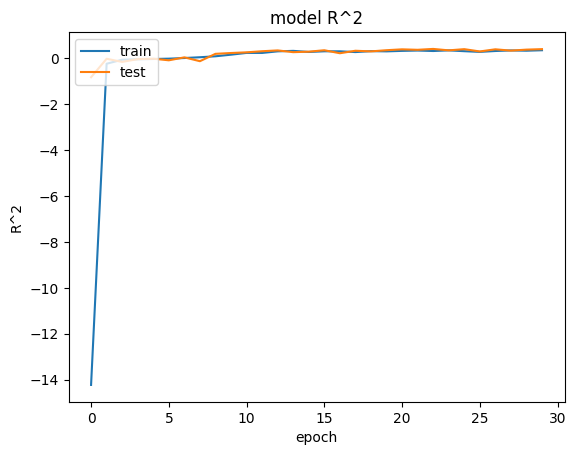

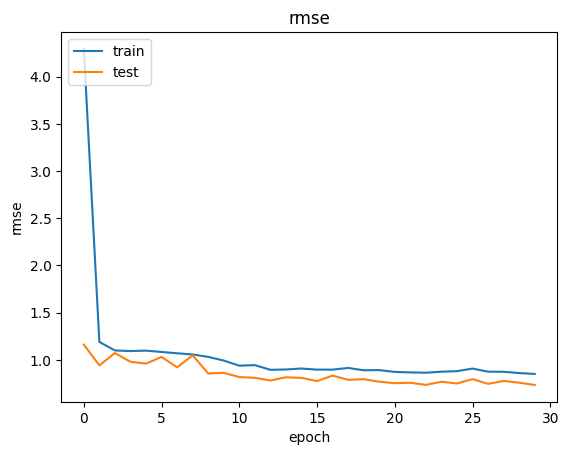

Saved model to disk
✅ Saved predictor_weigths_kor/kormodel0.weights.h5

=== Training predictor model 1 ===
Epoch 1/30
12/12 [==============================] - 7s 154ms/step - loss: 22.2191 - mse: 22.2191 - r_square: -11.7394 - rmse: 4.0791 - ccc: -0.0589 - val_loss: 2.9257 - val_mse: 2.9257 - val_r_square: -1.1243 - val_rmse: 1.3018 - val_ccc: -0.0038
Epoch 2/30
12/12 [==============================] - 0s 27ms/step - loss: 2.3145 - mse: 2.3145 - r_square: -0.3734 - rmse: 1.2197 - ccc: -4.4077e-04 - val_loss: 1.4136 - val_mse: 1.4136 - val_r_square: -0.0272 - val_rmse: 0.9749 - val_ccc: -9.7402e-04
Epoch 3/30
12/12 [==============================] - 0s 19ms/step - loss: 1.8105 - mse: 1.8105 - r_square: -0.0575 - rmse: 1.0839 - ccc: 0.0051 - val_loss: 1.6240 - val_mse: 1.6240 - val_r_square: -0.1700 - val_rmse: 1.0830 - val_ccc: -5.4636e-04
Epoch 4/30
12/12 [==============================] - 0s 18ms/step - loss: 1.8453 - mse: 1.8453 - r_square: -0.0993 - rmse: 1.1235 - ccc: 4.1635e-04 - 

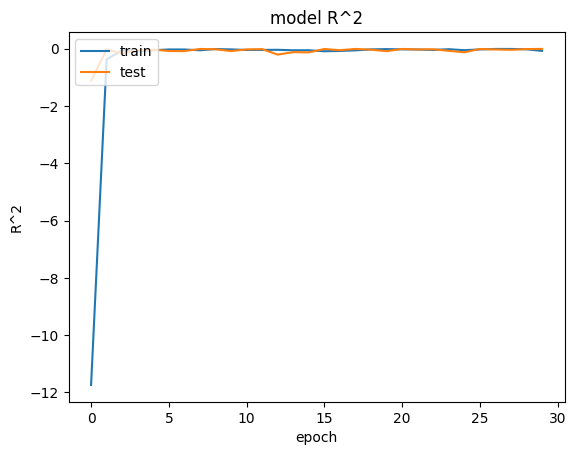

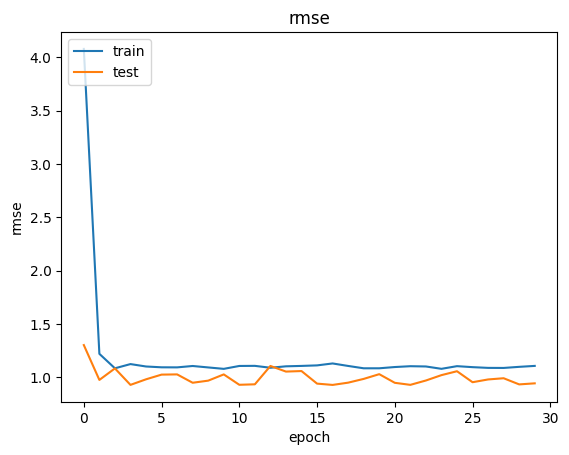

Saved model to disk
✅ Saved predictor_weigths_kor/kormodel1.weights.h5

=== Training predictor model 2 ===
Epoch 1/30
12/12 [==============================] - 6s 157ms/step - loss: 23.1355 - mse: 23.1355 - r_square: -12.3755 - rmse: 4.1874 - ccc: -0.0831 - val_loss: 3.1015 - val_mse: 3.1015 - val_r_square: -1.2504 - val_rmse: 1.3567 - val_ccc: -0.0079
Epoch 2/30
12/12 [==============================] - 0s 27ms/step - loss: 2.4265 - mse: 2.4265 - r_square: -0.4009 - rmse: 1.2765 - ccc: -0.0016 - val_loss: 1.4183 - val_mse: 1.4183 - val_r_square: -0.0303 - val_rmse: 0.9779 - val_ccc: -0.0018
Epoch 3/30
12/12 [==============================] - 0s 22ms/step - loss: 1.8394 - mse: 1.8394 - r_square: -0.0686 - rmse: 1.0997 - ccc: 0.0013 - val_loss: 1.5670 - val_mse: 1.5670 - val_r_square: -0.1308 - val_rmse: 1.0580 - val_ccc: -9.4800e-04
Epoch 4/30
12/12 [==============================] - 0s 24ms/step - loss: 1.7734 - mse: 1.7734 - r_square: -0.0594 - rmse: 1.1051 - ccc: 0.0039 - val_loss: 1.

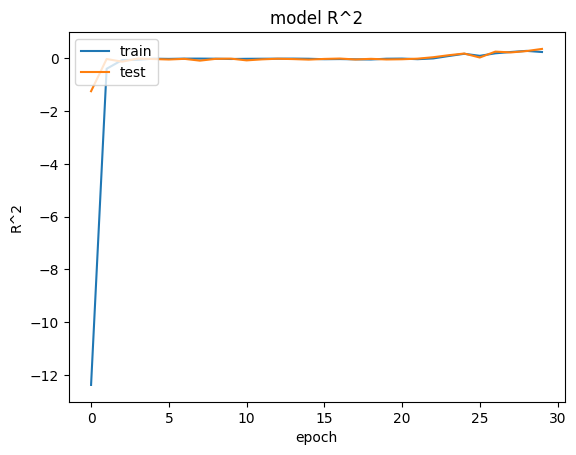

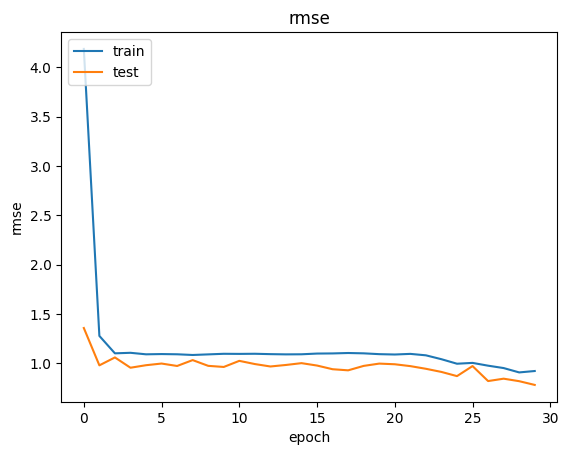

Saved model to disk
✅ Saved predictor_weigths_kor/kormodel2.weights.h5

=== Training predictor model 3 ===
Epoch 1/30
12/12 [==============================] - 7s 189ms/step - loss: 22.2313 - mse: 22.2313 - r_square: -11.4665 - rmse: 4.0777 - ccc: -0.0815 - val_loss: 2.7376 - val_mse: 2.7376 - val_r_square: -0.9898 - val_rmse: 1.2399 - val_ccc: -0.0058
Epoch 2/30
12/12 [==============================] - 1s 50ms/step - loss: 2.1558 - mse: 2.1558 - r_square: -0.2698 - rmse: 1.2113 - ccc: -0.0069 - val_loss: 1.3976 - val_mse: 1.3976 - val_r_square: -0.0205 - val_rmse: 0.9328 - val_ccc: -6.9917e-04
Epoch 3/30
12/12 [==============================] - 0s 32ms/step - loss: 1.8261 - mse: 1.8261 - r_square: -0.0594 - rmse: 1.1094 - ccc: 5.5666e-04 - val_loss: 1.5662 - val_mse: 1.5662 - val_r_square: -0.1303 - val_rmse: 1.0577 - val_ccc: -2.7210e-04
Epoch 4/30
12/12 [==============================] - 0s 31ms/step - loss: 1.7820 - mse: 1.7820 - r_square: -0.0446 - rmse: 1.1033 - ccc: 6.9234e-04 - 

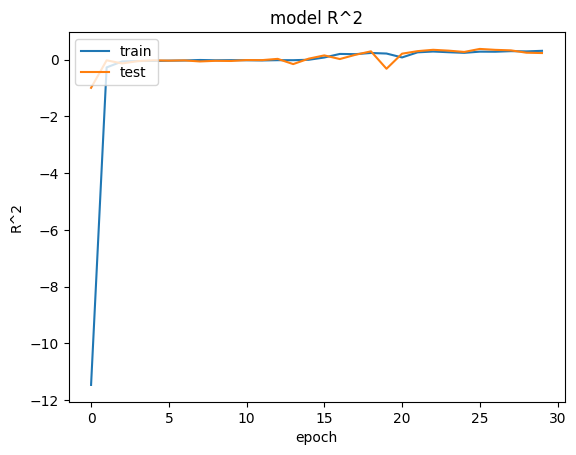

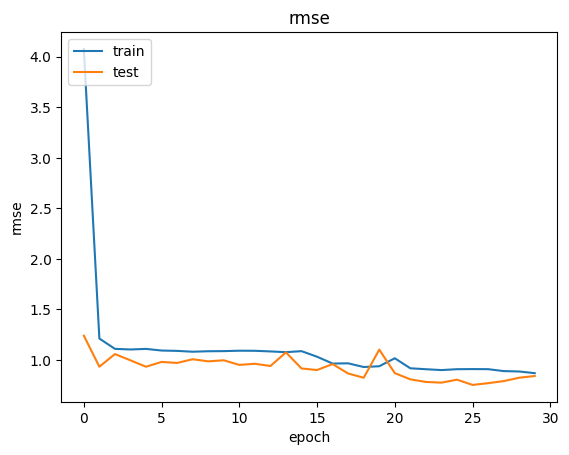

Saved model to disk
✅ Saved predictor_weigths_kor/kormodel3.weights.h5

=== Training predictor model 4 ===
Epoch 1/30
12/12 [==============================] - 8s 215ms/step - loss: 20.4628 - mse: 20.4628 - r_square: -10.7448 - rmse: 3.8466 - ccc: -0.0742 - val_loss: 2.3547 - val_mse: 2.3547 - val_r_square: -0.7151 - val_rmse: 1.1263 - val_ccc: -0.0028
Epoch 2/30
12/12 [==============================] - 1s 49ms/step - loss: 2.2069 - mse: 2.2069 - r_square: -0.2941 - rmse: 1.2374 - ccc: -9.3017e-04 - val_loss: 1.4007 - val_mse: 1.4007 - val_r_square: -0.0230 - val_rmse: 0.9312 - val_ccc: -3.5258e-04
Epoch 3/30
12/12 [==============================] - 0s 23ms/step - loss: 1.7972 - mse: 1.7972 - r_square: -0.0529 - rmse: 1.0832 - ccc: 0.0027 - val_loss: 1.7133 - val_mse: 1.7133 - val_r_square: -0.2316 - val_rmse: 1.1192 - val_ccc: -9.7544e-05
Epoch 4/30
12/12 [==============================] - 0s 26ms/step - loss: 1.8165 - mse: 1.8165 - r_square: -0.0582 - rmse: 1.1130 - ccc: -0.0013 - val

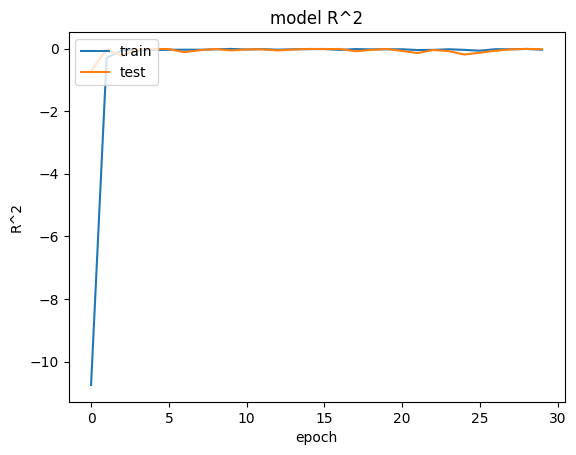

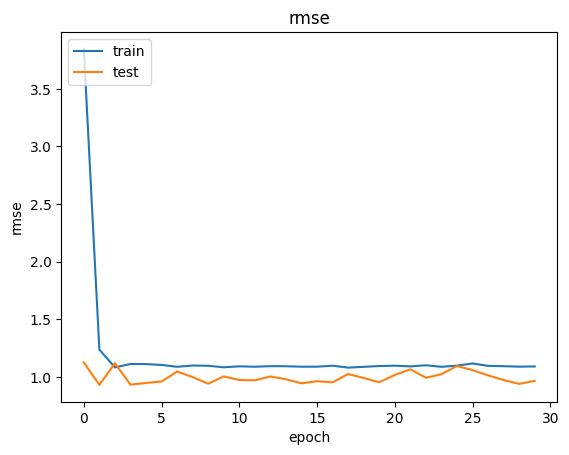

Saved model to disk
✅ Saved predictor_weigths_kor/kormodel4.weights.h5

✅ All 5 predictor models trained
total 16888
drwxr-xr-x 2 root root    4096 Jun 19 17:50 .
drwxr-xr-x 1 root root    4096 Jun 19 17:49 ..
-rw-r--r-- 1 root root 3454832 Jun 19 17:49 kormodel0.weights.h5
-rw-r--r-- 1 root root 3454832 Jun 19 17:50 kormodel1.weights.h5
-rw-r--r-- 1 root root 3454832 Jun 19 17:50 kormodel2.weights.h5
-rw-r--r-- 1 root root 3454832 Jun 19 17:50 kormodel3.weights.h5
-rw-r--r-- 1 root root 3454832 Jun 19 17:50 kormodel4.weights.h5


In [94]:
import os
os.makedirs('predictor_weigths_kor', exist_ok=True)

for i in range(5):
    print(f"\n=== Training predictor model {i} ===")
    predictor.model = predictor.loaded_models[i]
    predictor.train_model(data, searchParam=False)
    # Keras 3 requires '.weights.h5'; load_models() also accepts legacy '.hdf5'.
    save_path = f"predictor_weigths_kor/kormodel{i}.weights.h5"
    predictor.loaded_models[i].save_weights(save_path)
    print(f"✅ Saved {save_path}")

print("\n✅ All 5 predictor models trained")
!ls -la predictor_weigths_kor/

## 9. Train the base WGAN-GP

> Smoke test: `EPOCHS_GAN = 50`. Real: 5,000–10,000.

In [96]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import numpy as np
from wgan import WGANGP

import pandas as pd
df = pd.read_csv('data/data_clean_kop.csv')
smiles_raw = df[df.columns[0]].astype(str).tolist()

tok, _ = vocab.tokenize(smiles_raw)
X_enc = np.array(vocab.encode(tok))  # (n, max_len) — matches encoder Input(None,)
n = len(X_enc)

autoencoder.load_autoencoder_model(AE_WEIGHTS)
x_latent = autoencoder.smiles_to_latent_model.predict(X_enc)
print("Latent data shape:", x_latent.shape)

input_dim = 256
critic_layers_units = [256, 256, 256]
critic_lr = 0.0001; gp_weight = 10; z_dim = 64
generator_layers_units = [128, 256, 256, 256, 256]
generator_batch_norm_momentum = 0.9; generator_lr = 0.0001; batch_size = 64
critic_optimizer = 'adam'; generator_optimizer = 'adam'
critic_dropout = 0.2; generator_dropout = 0.2

gan = WGANGP(input_dim, critic_layers_units, critic_lr, critic_dropout, gp_weight,
             z_dim, generator_layers_units, generator_batch_norm_momentum,
             generator_lr, generator_dropout, batch_size,
             critic_optimizer, generator_optimizer)
print("✅ GAN built")

30/30 [==============================] - 3s 15ms/step
Latent data shape: (940, 256)
Model: "Critic"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 critic_input (InputLayer)   [(None, 256)]             0         
                                                                 
 critic_layer_0 (Dense)      (None, 256)               65792     
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 256)               0         
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 critic_layer_1 (Dense)      (None, 256)               65792     
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 256)               0         
                                          

In [ ]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import numpy as np, csv
from utils import evaluate_property, plot_hist_both

n_run = 'run_feedback_colab'
run_folder = 'GAN_model/' + n_run + '/'
for sub in ['', 'viz', 'generated_data', 'weights', 'feedbackGAN']:
    os.makedirs(os.path.join(run_folder, sub), exist_ok=True)

gan.epoch = 0
gan.autoencoder = autoencoder
gan.vocab = vocab

# How many valid molecules to sample for the before/after comparison.
# Decoding is sequential (one char at a time), so large values are slow on an
# undertrained model. Start small; raise once your models are well trained.
N_SAMPLE = 30        # ⬅️ raise to 200-1000 once training is solid

valid_before, perc_before, _ = gan.sample_valid_data(N_SAMPLE, run_folder, True)
pred_before, _ = evaluate_property(predictor, valid_before, 'kor')
print("Valid % before:", perc_before)

EPOCHS_FB = 50       # ⬅️ raise to 500 for real training
n_to_generate = 200
threshold = 5
info = 'max'

gan.train_feedbackGAN(x_latent, smiles_raw, batch_size, EPOCHS_FB, run_folder,
                      autoencoder, vocab, predictor, n_to_generate, threshold,
                      info, 'kor', print_every_n_epochs=10, critic_loops=5)

valid_after, perc_after, _ = gan.sample_valid_data(N_SAMPLE, run_folder, True)
pred_after, _ = evaluate_property(predictor, valid_after, 'kor')
print("\nValid % after:", perc_after)

/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Epochs 0: D_loss = 188.1497802734375, G_loss = -0.1383780986070633
!!!
sampling data...
1/1 [==============================] - 0s 50ms/step


[17:56:40] SMILES Parse Error: syntax error while parsing: Occccccccccc(
[17:56:40] SMILES Parse Error: check for mistakes around position 13:
[17:56:40] Occccccccccc(
[17:56:40] ~~~~~~~~~~~~^
[17:56:40] SMILES Parse Error: Failed parsing SMILES 'Occccccccccc(' for input: 'Occccccccccc('
[17:56:40] SMILES Parse Error: syntax error while parsing: Occcccccccc(((
[17:56:40] SMILES Parse Error: check for mistakes around position 13:
[17:56:40] Occcccccccc(((
[17:56:40] ~~~~~~~~~~~~^
[17:56:40] SMILES Parse Error: Failed parsing SMILES 'Occcccccccc(((' for input: 'Occcccccccc((('
[17:56:40] SMILES Parse Error: unclosed ring for input: 'ccccccccccc1'
[17:56:40] SMILES Parse Error: syntax error while parsing: ccccccccccc((
[17:56:40] SMILES Parse Error: check for mistakes around position 13:
[17:56:40] ccccccccccc((
[17:56:40] ~~~~~~~~~~~~^
[17:56:40] SMILES Parse Error: Failed parsing SMILES 'ccccccccccc((' for input: 'ccccccccccc(('
[17:56:40] SMILES Parse Error: syntax error while parsing:

Epochs 1: D_loss = 74.71109771728516, G_loss = -0.169434055685997
Epochs 2: D_loss = 35.30044174194336, G_loss = -0.13758166134357452
Epochs 3: D_loss = 18.783615112304688, G_loss = -0.1328515261411667
Epochs 4: D_loss = 12.213987350463867, G_loss = -0.12889330089092255
Epochs 5: D_loss = 8.79487133026123, G_loss = -0.11394121497869492
Epochs 6: D_loss = 6.110066890716553, G_loss = -0.1117861270904541
Epochs 7: D_loss = 4.2138237953186035, G_loss = -0.1077679768204689
Epochs 8: D_loss = 3.0454185009002686, G_loss = -0.10391315817832947
Epochs 9: D_loss = 1.9223034381866455, G_loss = -0.10388600826263428


Epochs 10: D_loss = 1.3620632886886597, G_loss = -0.09558463096618652
!!!
sampling data...
1/1 [==============================] - 0s 43ms/step


...

[18:09:19] non-ring atom 0 marked aromatic
[18:09:19] non-ring atom 0 marked aromatic
[18:09:19] SMILES Parse Error: syntax error while parsing: ccccccccccc(
[18:09:19] SMILES Parse Error: check for mistakes around position 12:
[18:09:19] ccccccccccc(
[18:09:19] ~~~~~~~~~~~^
[18:09:19] SMILES Parse Error: Failed parsing SMILES 'ccccccccccc(' for input: 'ccccccccccc('
[18:09:19] SMILES Parse Error: syntax error while parsing: ccccccccccc(
[18:09:19] SMILES Parse Error: check for mistakes around position 12:
[18:09:19] ccccccccccc(
[18:09:19] ~~~~~~~~~~~^
[18:09:19] SMILES Parse Error: Failed parsing SMILES 'ccccccccccc(' for input: 'ccccccccccc('
[18:09:19] non-ring atom 0 marked aromatic
[18:09:19] SMILES Parse Error: syntax error while parsing: ccccccccccc(
[18:09:19] SMILES Parse Error: check for mistakes around position 12:
[18:09:19] ccccccccccc(
[18:09:19] ~~~~~~~~~~~^
[18:09:19] SMILES Parse Error: Failed parsing SMILES 'ccccccccccc(' for input: 'ccccccccccc('
[18:09:19] non-ring

Epochs 31: D_loss = -0.2624850571155548, G_loss = -0.07828737050294876
Epochs 32: D_loss = -0.2654021382331848, G_loss = -0.09846393018960953
Epochs 33: D_loss = -0.23809564113616943, G_loss = -0.11884385347366333
Epochs 34: D_loss = -0.22240042686462402, G_loss = -0.11409471184015274
Epochs 35: D_loss = -0.21137775480747223, G_loss = -0.13468949496746063
Epochs 36: D_loss = -0.1906861513853073, G_loss = -0.13348309695720673
Epochs 37: D_loss = -0.1615844964981079, G_loss = -0.11850088834762573
Epochs 38: D_loss = -0.15266428887844086, G_loss = -0.09552085399627686
Epochs 39: D_loss = -0.13836751878261566, G_loss = -0.07636558264493942


Epochs 40: D_loss = -0.12259942293167114, G_loss = -0.0635635182261467
!!!
sampling data...
1/1 [==============================] - 0s 23ms/step


[18:12:51] SMILES Parse Error: syntax error while parsing: cccccccccc(
[18:12:51] SMILES Parse Error: check for mistakes around position 11:
[18:12:51] cccccccccc(
[18:12:51] ~~~~~~~~~~^
[18:12:51] SMILES Parse Error: Failed parsing SMILES 'cccccccccc(' for input: 'cccccccccc('
[18:12:51] non-ring atom 0 marked aromatic
[18:12:51] non-ring atom 0 marked aromatic
[18:12:51] non-ring atom 0 marked aromatic
[18:12:51] non-ring atom 0 marked aromatic
[18:12:51] non-ring atom 0 marked aromatic
[18:12:51] SMILES Parse Error: syntax error while parsing: cccccccccc(
[18:12:51] SMILES Parse Error: check for mistakes around position 11:
[18:12:51] cccccccccc(
[18:12:51] ~~~~~~~~~~^
[18:12:51] SMILES Parse Error: Failed parsing SMILES 'cccccccccc(' for input: 'cccccccccc('
[18:12:51] non-ring atom 0 marked aromatic
[18:12:51] non-ring atom 0 marked aromatic
[18:12:51] non-ring atom 0 marked aromatic
[18:12:51] SMILES Parse Error: syntax error while parsing: cccccccccc(
[18:12:51] SMILES Parse Err

Epochs 41: D_loss = -0.1058710366487503, G_loss = -0.06191618740558624
Epochs 42: D_loss = -0.091069296002388, G_loss = -0.0580533891916275
Epochs 43: D_loss = -0.08199076354503632, G_loss = -0.04616330936551094
Epochs 44: D_loss = -0.07299160957336426, G_loss = -0.03105117939412594
Epochs 45: D_loss = -0.06757588684558868, G_loss = -0.025179699063301086
Epochs 46: D_loss = -0.05890049412846565, G_loss = -0.007102233823388815
Epochs 47: D_loss = -0.052050769329071045, G_loss = -0.001152451615780592
Epochs 48: D_loss = -0.0572754442691803, G_loss = -0.0006273689796216786
Epochs 49: D_loss = -0.055655162781476974, G_loss = -0.015916036441922188

✅ Base GAN trained, weights saved to GAN_model/GAN_weights/


## 10. Run the FeedbackGAN loop

Each epoch: generate → score with predictor → replace weakest training samples
with best generated, pushing toward higher predicted pIC50.

In [100]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import numpy as np, csv
from Utils import evaluate_property, plot_hist_both

n_run = 'run_feedback_colab'
run_folder = 'GAN_model/' + n_run + '/'
for sub in ['', 'viz', 'generated_data', 'weights', 'feedbackGAN']:
    os.makedirs(os.path.join(run_folder, sub), exist_ok=True)

gan.epoch = 0
gan.autoencoder = autoencoder
gan.vocab = vocab

# تعداد مولکول‌های معتبر برای مقایسه قبل/بعد.
# decode کاراکتر‌به‌کاراکتر است و کند، پس روی مدل آموزش‌ندیده عدد بزرگ خیلی طول می‌کشد.
# با عدد کوچک شروع کن، بعد از آموزش واقعی بالا ببر.
N_SAMPLE = 30        # ⬅️ بعد از آموزش کامل به 200-1000 ببر

valid_before, perc_before, _ = gan.sample_valid_data(N_SAMPLE, run_folder, True)
pred_before, _ = evaluate_property(predictor, valid_before, 'kor')
print("Valid % before:", perc_before)

EPOCHS_FB = 50       # ⬅️ برای آموزش واقعی به 500 ببر
n_to_generate = 200
threshold = 5
info = 'max'

gan.train_feedbackGAN(x_latent, smiles_raw, batch_size, EPOCHS_FB, run_folder,
                      autoencoder, vocab, predictor, n_to_generate, threshold,
                      info, 'kor', print_every_n_epochs=10, critic_loops=5)

valid_after, perc_after, _ = gan.sample_valid_data(N_SAMPLE, run_folder, True)
pred_after, _ = evaluate_property(predictor, valid_after, 'kor')
print("\nValid % after:", perc_after)

sampling data...
1/1 [==============================] - 0s 23ms/step


[18:58:53] SMILES Parse Error: syntax error while parsing: ccccccccccc(
[18:58:53] SMILES Parse Error: check for mistakes around position 12:
[18:58:53] ccccccccccc(
[18:58:53] ~~~~~~~~~~~^
[18:58:53] SMILES Parse Error: Failed parsing SMILES 'ccccccccccc(' for input: 'ccccccccccc('
[18:58:53] SMILES Parse Error: syntax error while parsing: cccccccccc(
[18:58:53] SMILES Parse Error: check for mistakes around position 11:
[18:58:53] cccccccccc(
[18:58:53] ~~~~~~~~~~^
[18:58:53] SMILES Parse Error: Failed parsing SMILES 'cccccccccc(' for input: 'cccccccccc('
[18:58:53] non-ring atom 0 marked aromatic
[18:58:53] SMILES Parse Error: syntax error while parsing: cccccccccc(
[18:58:53] SMILES Parse Error: check for mistakes around position 11:
[18:58:53] cccccccccc(
[18:58:53] ~~~~~~~~~~^
[18:58:53] SMILES Parse Error: Failed parsing SMILES 'cccccccccc(' for input: 'cccccccccc('
[18:58:53] non-ring atom 0 marked aromatic
[18:58:53] non-ring atom 0 marked aromatic
[18:58:53] SMILES Parse Error

1/1 [==============================] - 0s 22ms/step


[18:59:18] non-ring atom 0 marked aromatic
[18:59:18] non-ring atom 0 marked aromatic
[18:59:18] non-ring atom 0 marked aromatic
[18:59:18] non-ring atom 0 marked aromatic
[18:59:18] SMILES Parse Error: syntax error while parsing: cccccccccc(
[18:59:18] SMILES Parse Error: check for mistakes around position 11:
[18:59:18] cccccccccc(
[18:59:18] ~~~~~~~~~~^
[18:59:18] SMILES Parse Error: Failed parsing SMILES 'cccccccccc(' for input: 'cccccccccc('
[18:59:18] non-ring atom 0 marked aromatic
[18:59:18] SMILES Parse Error: syntax error while parsing: cccccccccc(
[18:59:18] SMILES Parse Error: check for mistakes around position 11:
[18:59:18] cccccccccc(
[18:59:18] ~~~~~~~~~~^
[18:59:18] SMILES Parse Error: Failed parsing SMILES 'cccccccccc(' for input: 'cccccccccc('
[18:59:18] non-ring atom 0 marked aromatic
[18:59:18] non-ring atom 0 marked aromatic
[18:59:18] non-ring atom 0 marked aromatic
[18:59:18] non-ring atom 0 marked aromatic
[18:59:18] non-ring atom 0 marked aromatic
[18:59:18] n

1/1 [==============================] - 0s 24ms/step


KeyboardInterrupt: 

In [ ]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
from generate import generate_molecules

# تولید مولکول‌های معتبر و یکتای تصادفی، امتیازدهی با predictor
df_gen = generate_molecules(
    gan, autoencoder, vocab,
    n=30,                      # چند مولکول می‌خواهی (کوچک شروع کن)
    predictor=predictor,
    property_identifier='kor'
)

print(f"\n{len(df_gen)} مولکول تولید شد\n")
df_gen.head(20)

## 11. Compare before vs after

In [ ]:
import numpy as np
pred_before = np.array(pred_before).astype(float)
pred_after  = np.array(pred_after).astype(float)

print("Mean pIC50 before:", pred_before.mean())
print("Mean pIC50 after :", pred_after.mean())
print("Shift:", pred_after.mean() - pred_before.mean())

diff = plot_hist_both(pred_before, pred_after, 'kor')
print("\nDifference between averages:", diff)

In [ ]:
import csv, os
with open(os.path.join(run_folder, 'generated_molecules.csv'), 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['SMILES'])
    for s in valid_after:
        writer.writerow([s])
print("✅ Saved generated_molecules.csv")

import pandas as pd
out = pd.DataFrame({'SMILES': valid_after[:len(pred_after)], 'pred_pIC50': pred_after})
out = out.sort_values('pred_pIC50', ascending=False)
out.head(15)

## 12. (Optional) Save results to Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os
dest = '/content/drive/MyDrive/FeedbackGAN_results/'
os.makedirs(dest, exist_ok=True)

for src in ['AE/scratch_ae', 'GAN_model/GAN_weights', 'predictor_weigths_kor',
            'GAN_model/run_feedback_colab']:
    if os.path.exists(src):
        d = os.path.join(dest, src.replace('/', '_'))
        shutil.copytree(src, d, dirs_exist_ok=True)
        print("Copied", src, "->", d)
print("\n✅ Saved to Google Drive")

---
## Troubleshooting

**Small epochs on purpose.** `EPOCHS_AE=2`, `EPOCHS_GAN=50`, `EPOCHS_FB=50` are
smoke-test values. Raise them (comments mark each) for real results.

**"Embedding index out of range":** vocab mismatch. Re-run Section 4 and make sure
the same `vocab` object flows into autoencoder, predictor, and GAN.

**Out of GPU RAM:** lower `batch_size` from 64 to 32.

**Slow `sample_valid_data` at epoch 0:** normal — an untrained generator makes few
valid SMILES. The MAX_ATTEMPTS guard prevents an infinite loop.

**Keras errors / "filepath must end in .keras":** you're on Keras 3. Re-run
Section 2 and restart the session so `TF_USE_LEGACY_KERAS=1` takes effect.

---
*Built for [0x41hd](https://github.com/0x41hd)*